# Data Loading

In [4]:
import pickle

with open("data/processed_sentences.pkl", "rb") as f:
    sentences = pickle.load(f)

with open("data/frequent_words.pkl", "rb") as f:
    frequent_words = pickle.load(f)

with open("data/rare_words.pkl", "rb") as f:
    rare_words = pickle.load(f)

print(len(sentences))

2027259


# Experimental Setup

### Objective
The goal of this study is to compare CBOW and Skip-gram architectures in terms of:
- training efficiency
- representation quality
- performance on frequent vs rare words
- downstream task performance

### Controlled Variables
To ensure fair comparison:
- same corpus
- same preprocessing
- same vocabulary (min_count=5)
- same training parameters (except architecture)

### Model Configurations
We train 6 models:

| Model | Architecture | vector_size | window | negative | epochs |
|------|-------------|------------|--------|----------|--------|
| CBOW-1 | CBOW | 100 | 5 | 5 | 5 |
| CBOW-2 | CBOW | 200 | 5 | 5 | 5 |
| CBOW-3 | CBOW | 100 | 10 | 5 | 5 |
| SG-1   | Skip-gram | 100 | 5 | 5 | 5 |
| SG-2   | Skip-gram | 200 | 5 | 5 | 5 |
| SG-3   | Skip-gram | 100 | 10 | 5 | 5 |

### Implementation Details
- Library: Gensim Word2Vec
- Training: negative sampling
- Tokenization: preprocessed dataset
- Random seed: fixed

# Training models

Each model is trained on the same preprocessed dataset using identical conditions,
except for the architecture (CBOW vs Skip-gram) and selected hyperparameters.

We measure:
- total training time
- training stability (via logs)

All models are trained using negative sampling.
Random seed is fixed to ensure reproducibility.

### Model configurations

In [5]:
!pip install gensim

In [6]:
import time
import pickle
import random
import numpy as np
from gensim.models import Word2Vec

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

configs = [
    {"name": "CBOW-1", "sg": 0, "vector_size": 100, "window": 5},
    {"name": "CBOW-2", "sg": 0, "vector_size": 200, "window": 5},
    {"name": "CBOW-3", "sg": 0, "vector_size": 100, "window": 10},

    {"name": "SG-1", "sg": 1, "vector_size": 100, "window": 5},
    {"name": "SG-2", "sg": 1, "vector_size": 200, "window": 5},
    {"name": "SG-3", "sg": 1, "vector_size": 100, "window": 10},
]

### Training

In [7]:
def train_model(sentences, config):
    print(f"\nTraining {config['name']}...")

    start_time = time.time()

    model = Word2Vec(
        sentences=sentences,
        vector_size=config["vector_size"],
        window=config["window"],
        sg=config["sg"],  # 0 = CBOW, 1 = Skip-gram
        negative=5,
        min_count=1,
        workers=4,
        seed=SEED,
        epochs=5
    )

    end_time = time.time()
    training_time = end_time - start_time

    print(f"{config['name']} done in {training_time:.2f} sec")

    return model, training_time

In [8]:
import os
os.makedirs("models", exist_ok=True)

models = {}
training_times = {}

for config in configs:
    model, t = train_model(sentences, config)

    models[config["name"]] = model
    training_times[config["name"]] = t
    model.save(f"models/{config['name']}.model")


Training CBOW-1...
CBOW-1 done in 301.34 sec

Training CBOW-2...
CBOW-2 done in 359.30 sec

Training CBOW-3...
CBOW-3 done in 301.00 sec

Training SG-1...
SG-1 done in 855.53 sec

Training SG-2...
SG-2 done in 1136.19 sec

Training SG-3...
SG-3 done in 1348.07 sec


### Time Summary

In [9]:
import pandas as pd

results_df = pd.DataFrame([
    {
        "model": name,
        "architecture": "Skip-gram" if "SG" in name else "CBOW",
        "vector_size": next(c["vector_size"] for c in configs if c["name"] == name),
        "window": next(c["window"] for c in configs if c["name"] == name),
        "training_time_sec": training_times[name]
    }
    for name in training_times
])

results_df

,model,architecture,vector_size,window,training_time_sec
0,CBOW-1,CBOW,100,5,301.343469
1,CBOW-2,CBOW,200,5,359.301100
2,CBOW-3,CBOW,100,10,300.998237
3,SG-1,Skip-gram,100,5,855.528783
4,SG-2,Skip-gram,200,5,1136.191992
5,SG-3,Skip-gram,100,10,1348.070434


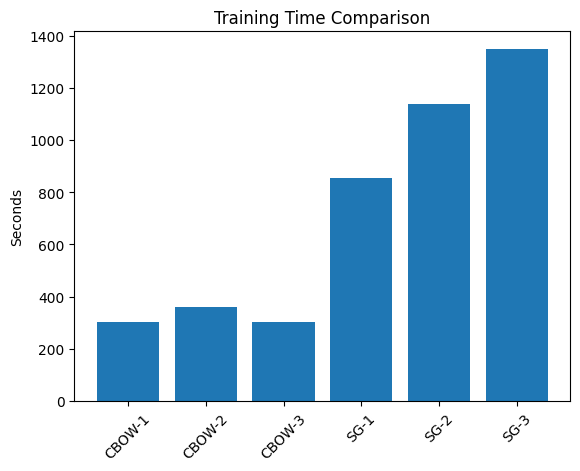

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["model"], results_df["training_time_sec"])
plt.xticks(rotation=45)
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

# Evaluation
All experiments are repeated with identical seeds to ensure reproducibility.

## Intrinsic Evaluation
We evaluate embeddings using:

1. Word similarity
2. Word analogies

### Word similarity

In [28]:
import pandas as pd
from scipy.stats import spearmanr

def evaluate_simlex_local(models, file_path):
    df = pd.read_csv(file_path, sep='\t', on_bad_lines='skip')
    test_pairs = df[['word1', 'word2', 'SimLex999']].values.tolist()

    results = {}

    for name, model in models.items():
        model_scores = []
        human_scores = []

        for w1, w2, human_sim in test_pairs:
            w1, w2 = str(w1).lower(), str(w2).lower()

            if w1 in model.wv and w2 in model.wv:
                # We calculate the cosine similarity of the model
                model_sim = model.wv.similarity(w1, w2)

                model_scores.append(model_sim)
                human_scores.append(human_sim)

        if len(model_scores) > 1:
            # Spearman correlation shows the relationship between the rating ranks
            corr, _ = spearmanr(human_scores, model_scores)
            results[name] = {
                "Spearman_Corr": round(corr, 4),
                "Pairs_Found": len(model_scores),
                "Coverage": f"{round(len(model_scores) / len(test_pairs) * 100, 1)}%"
            }
        else:
            results[name] = "Insufficient data (words not in vocab)"

    return pd.DataFrame(results).T


res_simlex = evaluate_simlex_local(models, 'data/SimLex-999.txt')
print(res_simlex)


       Spearman_Corr Pairs_Found Coverage
CBOW-1        0.2346         993    99.4%
CBOW-2        0.2492         993    99.4%
CBOW-3        0.2374         993    99.4%
SG-1          0.2818         993    99.4%
SG-2          0.3195         993    99.4%
SG-3          0.2671         993    99.4%


### Word analogies: Semantic & Syntactic

In [14]:
import pandas as pd

def evaluate_google_analogies(models, file_path):
    final_results = {}

    for name, model in models.items():
        overall_acc, sections = model.wv.evaluate_word_analogies(file_path)

        semantic_acc = 0
        syntactic_acc = 0
        sem_count = 0
        syn_count = 0

        for section in sections:
            section_name = section['section']
            # We count the number of correct answers
            correct = len(section['correct'])
            total = len(section['correct']) + len(section['incorrect'])

            if total == 0: continue

            # Separate by section names
            # Semantics: capitals, currencies, family, countries
            # Syntax: degrees of comparison, plural
            if any(key in section_name for key in ['capital-common-countries', 'currency', 'family']):
                semantic_acc += correct
                sem_count += total
            elif any(key in section_name for key in ['gram1-adjective-to-adverb', 'gram3-comparative', 'gram8-plural']):
                syntactic_acc += correct
                syn_count += total

        final_results[name] = {
            "Semantic Accuracy": round(semantic_acc / sem_count, 4) if sem_count > 0 else 0,
            "Syntactic Accuracy": round(syntactic_acc / syn_count, 4) if syn_count > 0 else 0,
            "Total Coverage": sem_count + syn_count
        }

    return pd.DataFrame(final_results).T

res = evaluate_google_analogies(models, 'data/questions-words.txt')
print(res)


        Semantic Accuracy  Syntactic Accuracy  Total Coverage
CBOW-1             0.3800              0.4182          5314.0
CBOW-2             0.3908              0.4469          5314.0
CBOW-3             0.3951              0.4401          5314.0
SG-1               0.4355              0.3589          5314.0
SG-2               0.4572              0.4024          5314.0
SG-3               0.4626              0.3539          5314.0


## Extrinsic Evaluation
Embeddings are used as input features for a text classification task.
Sentence representation = average of word embeddings.
Classifier = Logistic Regression

In [17]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from gensim.utils import simple_preprocess

# 4 contrasting topics
categories = ['sci.space', 'rec.autos', 'talk.politics.guns', 'comp.graphics']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))

# Tokenizing texts
X_raw = [simple_preprocess(text) for text in newsgroups.data]
y = newsgroups.target

def sentence_vector(model, sentence):
    # Create a list of vectors for words that are in the model's vocabulary
    vectors = [model.wv[w] for w in sentence if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

def evaluate_classifier(model, X, y):
    # Converting texts into vectors
    X_vec = np.array([sentence_vector(model, s) for s in X])
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)

    # Training a classifier
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    return accuracy_score(y_test, y_pred)

classification_results = {}

for name, model in models.items():
    acc = evaluate_classifier(model, X_raw, y)
    classification_results[name] = round(acc, 4)

print("Classification accuracy:")
print(pd.Series(classification_results))


Classification accuracy:
CBOW-1    0.7526
CBOW-2    0.7681
CBOW-3    0.7668
SG-1      0.7940
SG-2      0.8174
SG-3      0.8018
dtype: float64


## Rare vs Frequent Analysis
We evaluate performance separately on:
- frequent words (top 10%)
- rare words (bottom 10% within filtered vocab)

In [18]:
import numpy as np
import pandas as pd

def evaluate_density(model, words):
    sims = []
    # Check that words are in the dictionary
    valid_words = [w for w in words if w in model.wv]

    for w in valid_words:
        neighbors = model.wv.most_similar(w, topn=5)
        avg_sim = np.mean([score for _, score in neighbors])
        sims.append(avg_sim)

    return round(np.mean(sims), 4) if sims else 0

density_results = []

for name, model in models.items():
    density_results.append({
        "Model": name,
        "Freq_Density": evaluate_density(model, frequent_words),
        "Rare_Density": evaluate_density(model, rare_words),
        "Gap": None
    })

df_density = pd.DataFrame(density_results).set_index("Model")
df_density["Gap"] = df_density["Freq_Density"] - df_density["Rare_Density"]

print(df_density)


        Freq_Density  Rare_Density     Gap
Model                                     
CBOW-1        0.7261        0.7953 -0.0692
CBOW-2        0.6833        0.7567 -0.0734
CBOW-3        0.7210        0.7446 -0.0236
SG-1          0.7502        0.9104 -0.1602
SG-2          0.6746        0.8883 -0.2137
SG-3          0.7479        0.8939 -0.1460


## Qualitative Analysis
We manually inspect nearest neighbors

In [19]:
import pandas as pd

# Group test words into categories
test_categories = {
    "Concrete": ["apple", "table", "car"],
    "Abstract": ["justice", "love", "freedom", "time"],
    "Actions": ["run", "think", "eat"],
    "Properties": ["beautiful", "fast", "cold"]
}

def compare_models_qualitative(models, categories, topn=5):
    all_data = []

    for cat_name, words in categories.items():
        for word in words:
            row = {"Category": cat_name, "Word": word}

            for model_name, model in models.items():
                if word in model.wv:
                    # We get the top neighbors and glue them into a string for compactness
                    neighbors = model.wv.most_similar(word, topn=topn)
                    neighbors_str = ", ".join([f"{n[0]} ({n[1]:.2f})" for n in neighbors])
                    row[model_name] = neighbors_str
                else:
                    row[model_name] = "NOT_IN_VOCAB"

            all_data.append(row)

    return pd.DataFrame(all_data)

# Running an analysis
comparison_df = compare_models_qualitative(models, test_categories)

# Display settings
pd.set_option('display.max_colwidth', None)
print(comparison_df)


      Category       Word  \
0     Concrete      apple   
1     Concrete      table   
2     Concrete        car   
3     Abstract    justice   
4     Abstract       love   
5     Abstract    freedom   
6     Abstract       time   
7      Actions        run   
8      Actions      think   
9      Actions        eat   
10  Properties  beautiful   
11  Properties       fast   
12  Properties       cold   

                                                                                    CBOW-1  \
0                app (0.70), smartphone (0.69), ios (0.68), microsoft (0.68), intel (0.67)   
1           column (0.62), periodic (0.62), tables (0.61), diagram (0.60), brackets (0.57)   
2              truck (0.82), vehicle (0.77), cars (0.75), pickup (0.74), motorcycle (0.73)   
3         counsel (0.60), supreme (0.59), equality (0.59), judicial (0.59), defense (0.58)   
4                kiss (0.72), smile (0.68), happiness (0.65), tears (0.64), sadness (0.64)   
5   equality (0.73), democrac

### PCA visualization

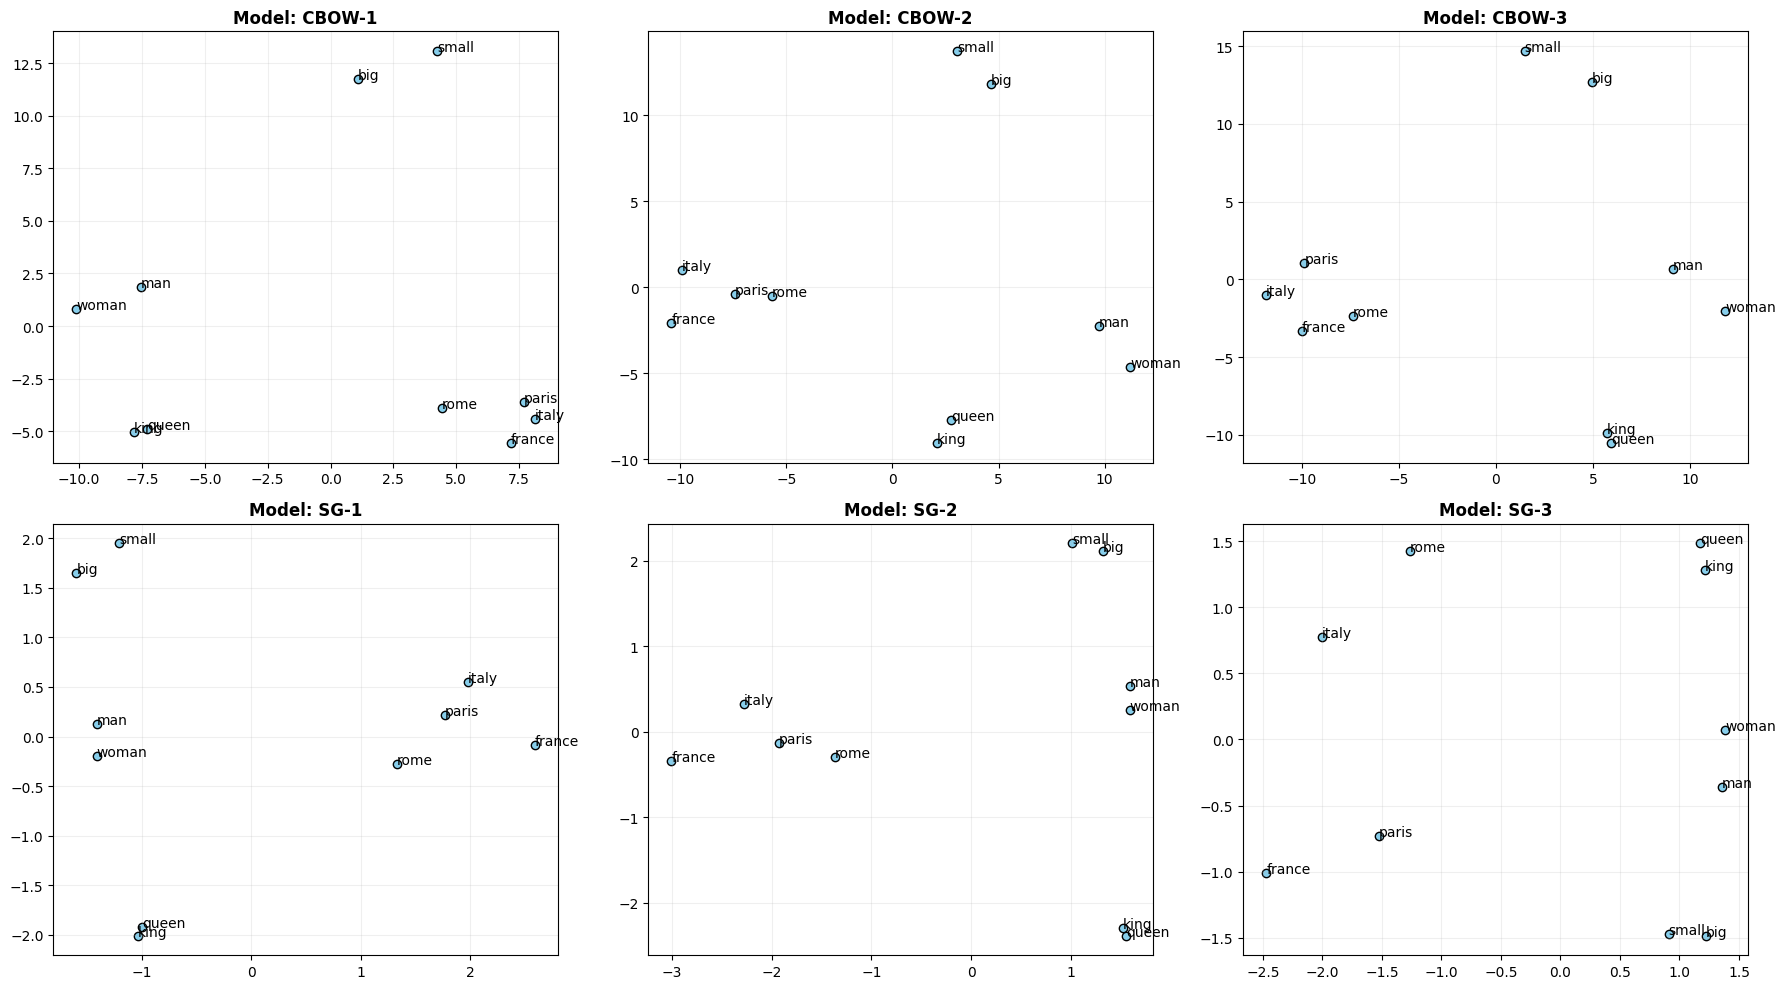

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_models_grid(models_dict, words):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    cbow_keys = ["CBOW-1", "CBOW-2", "CBOW-3"]
    sg_keys = ["SG-1", "SG-2", "SG-3"]
    grid_keys = [cbow_keys, sg_keys]

    for row_idx, keys in enumerate(grid_keys):
        for col_idx, key in enumerate(keys):
            ax = axes[row_idx, col_idx]
            model = models_dict[key]

            valid_words = [w for w in words if w in model.wv]
            vectors = [model.wv[w] for w in valid_words]

            if vectors:
                reduced = PCA(n_components=2).fit_transform(vectors)

                ax.scatter(reduced[:, 0], reduced[:, 1], c='skyblue', edgecolors='k')
                for i, word in enumerate(valid_words):
                    ax.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=10)

                ax.set_title(f"Model: {key}", fontsize=12, fontweight='bold')
                ax.grid(True, alpha=0.2)
            else:
                ax.set_title(f"{key} (No Data)")

    plt.tight_layout()
    plt.show()

words = ["king", "queen", "man", "woman", "paris", "france", "rome", "italy", "big", "small"]
plot_models_grid(models, words)


To visualize embedding structure, we applied PCA to reduce vector dimensionality to 2D.

Skip-gram embeddings show more coherent semantic clusters (e.g., countries, gender pairs), while CBOW embeddings appear more compact but less semantically structured.

This supports previous findings that Skip-gram better captures global semantic relationships.

## Final summary table

In [37]:
import pandas as pd


# SimLex
simlex_df = res_simlex.copy()
simlex_df = simlex_df.rename(columns={
    "Spearman_Corr": "SimLex_Corr"
})

simlex_df = simlex_df.drop(columns=["Pairs_Found", "Coverage"], errors="ignore")


# Analogies
analogies_df = res.copy()
analogies_df = analogies_df.rename(columns={
    "Semantic Accuracy": "Semantic_Acc",
    "Syntactic Accuracy": "Syntactic_Acc"
})

analogies_df = analogies_df.drop(columns=["Total Coverage"], errors="ignore")

# Classification
clf_df = pd.DataFrame(classification_results.items(), columns=["Model", "Classification_Acc"])
clf_df = clf_df.set_index("Model")

# Density
density_df = df_density.copy()

# MERGE ALL
final_df = simlex_df \
    .join(analogies_df) \
    .join(clf_df) \
    .join(density_df)


training_times = {
    "CBOW-1": 301,
    "CBOW-2": 359,
    "CBOW-3": 301,
    "SG-1": 855,
    "SG-2": 1136,
    "SG-3": 1348
}

final_df["Time_sec"] = final_df.index.map(training_times)


final_df = final_df.round(4)
final_df

,SimLex_Corr,Semantic_Acc,Syntactic_Acc,Classification_Acc,Freq_Density,Rare_Density,Gap,Time_sec
CBOW-1,0.2346,0.3800,0.4182,0.7526,0.7261,0.7953,-0.0692,301
CBOW-2,0.2492,0.3908,0.4469,0.7681,0.6833,0.7567,-0.0734,359
CBOW-3,0.2374,0.3951,0.4401,0.7668,0.7210,0.7446,-0.0236,301
SG-1,0.2818,0.4355,0.3589,0.7940,0.7502,0.9104,-0.1602,855
SG-2,0.3195,0.4572,0.4024,0.8174,0.6746,0.8883,-0.2137,1136
SG-3,0.2671,0.4626,0.3539,0.8018,0.7479,0.8939,-0.1460,1348


# Limitations

### Data Preparation Limitation

- rare words defined after min_count filtering
- simple tokenization
- simple English corpus

### Convergence Analysis limitation

Since Gensim does not allow convenient tracking of loss across epochs, we evaluate convergence indirectly – using the final metrics of models trained in an equal number of iterations.

### Evaluation Limitations

Only 6 selected analogy categories were used to separate semantic and syntactic relations



# Results & Discussion

In [38]:
final_df

,SimLex_Corr,Semantic_Acc,Syntactic_Acc,Classification_Acc,Freq_Density,Rare_Density,Gap,Time_sec
CBOW-1,0.2346,0.3800,0.4182,0.7526,0.7261,0.7953,-0.0692,301
CBOW-2,0.2492,0.3908,0.4469,0.7681,0.6833,0.7567,-0.0734,359
CBOW-3,0.2374,0.3951,0.4401,0.7668,0.7210,0.7446,-0.0236,301
SG-1,0.2818,0.4355,0.3589,0.7940,0.7502,0.9104,-0.1602,855
SG-2,0.3195,0.4572,0.4024,0.8174,0.6746,0.8883,-0.2137,1136
SG-3,0.2671,0.4626,0.3539,0.8018,0.7479,0.8939,-0.1460,1348


## Training Efficiency

Training time differs significantly between architectures.

CBOW models are much faster:
* **CBOW-1**: 301 sec
* **CBOW-2**: 359 sec
* **CBOW-3**: 301 sec

Skip-gram models are slower:
* **SG-1**: 855 sec
* **SG-2**: 1136 sec
* **SG-3**: 1348 sec

Skip-gram is about 3–4 times slower than CBOW. Training takes more time when vector size and window size increase. SG-3 is the slowest because it uses a large window (10) and Skip-gram.

---

## Intrinsic Evaluation
### 1. Word Similarity (SimLex-999)

We tested the models using the SimLex-999 dataset. It measures word similarity based on human scores. We used Spearman correlation to check the results.

Skip-gram is better than CBOW in all tests:
* **SG-2**: 0.3195 (Best result)
* **SG-1**: 0.2818
* **SG-3**: 0.2671

CBOW models have lower scores. The best CBOW model is **CBOW-2** (0.2492).

These results show that Skip-gram understands word meanings better than CBOW. Also, larger vector sizes improve performance (CBOW-2 > CBOW-1 and SG-2 > SG-1). Higher dimensions help the model capture better relationships between words.

The coverage is 99.4%, which means the models know almost all words in the dataset.
### 2. Word Analogies
#### 2.1 Semantic:

Skip-gram models are much better than CBOW at semantic tasks. **SG-3** has the best result (0.4626), followed by **SG-2** (0.4572) and **SG-1** (0.4355). CBOW models are weaker; the best one is **CBOW-3** (0.3951).

This shows that Skip-gram captures the meaning and relationships between words more effectively.

For both types, the third setup (window = 10) works best. This means a larger window helps the model understand the general context of a word.

#### 2.2 Syntactic:

In this test, CBOW models are better than Skip-gram. **CBOW-2** has the highest accuracy (0.4469), and **CBOW-3** is close (0.4401). Skip-gram models are less accurate; the best is **SG-2** (0.4024).

This suggests that CBOW is better at learning grammar and local word patterns.

The second setup (vector size = 200, window = 5) gives the best results for both. This means grammar is easier to learn with higher dimensions and smaller windows that focus on nearby words.

---
## Extrinsic Evaluation (Text Classification)

We tested the embeddings using a Logistic Regression classifier. We used averaged word vectors to represent sentences.

Skip-gram models performed better than CBOW in all tests:
* **SG-2**: 0.8174 accuracy (Best result)
* **SG-3**: 0.8018
* **SG-1**: 0.7940

CBOW models had lower accuracy; the best was **CBOW-2** (0.7681).

These results show that Skip-gram provides better features for real-world tasks. The 5% difference is a big improvement for a simple classifier. The second setup (vector size = 200, window = 5) worked best for both architectures. This shows that higher dimensions and a medium window help balance meaning and noise.

---

## Rare vs Frequent Word Analysis

We compared how models handle frequent and rare words by checking their embedding density.

In all models, rare words are closer to their neighbors than frequent words. This creates a "negative gap," which is more visible in Skip-gram:
* **SG-2**: –0.2137 (Large gap)
* **CBOW-2**: –0.0734 (Small gap)

This means rare words in Skip-gram form very tight clusters. Skip-gram learns more specific context for rare words because it updates vectors for each "word-context" pair separately. CBOW averages the context, so its vectors are more general and less precise for rare words.

However, high density does not always mean better quality—it can sometimes be a sign of overfitting. Overall, Skip-gram is more sensitive to rare words, while CBOW creates more uniform vectors across the vocabulary.

---

## Qualitative Analysis

We compared the nearest neighbors of words to see how CBOW and Skip-gram differ.

CBOW models usually find general and very common words. For example, for **"apple"**, CBOW shows words like **"app"**, **"microsoft"**, and **"intel"**. These are popular terms from the general text.

Skip-gram finds more specific and rare words. For **"apple"**, it shows **"macintosh"**, **"imac"**, and **"iwork"**. This shows Skip-gram focuses more on precise meanings.

This pattern is visible in other categories:
* **Abstract words** ("freedom", "justice"): Skip-gram finds specific terms, while CBOW finds general ones.
* **Actions** ("eat"): Skip-gram shows detailed words like **"pollinate"**, while CBOW shows simple verbs like **"feed"**.
* **Properties** ("fast", "cold"): Both work well, but Skip-gram finds more diverse words.

In summary, Skip-gram embeddings are more detailed and rich. CBOW embeddings are more stable and focus on common patterns. These results match our earlier tests: Skip-gram captures deep meaning, while CBOW provides more general representations.



# Conclusion

### Overall Comparison and Key Findings

This study provides a comprehensive comparison of CBOW and Skip-gram architectures across multiple evaluation dimensions, including training efficiency, intrinsic quality, downstream performance, and behavior on rare versus frequent words.

**1. Training Efficiency**

CBOW demonstrates a clear advantage in computational efficiency, training approximately 3–4 times faster than Skip-gram across all configurations. This makes CBOW a practical choice in resource-constrained environments or when rapid experimentation is required.

However, this efficiency comes at the cost of representation quality.

**2. Semantic vs Syntactic Trade-off**

The results reveal a consistent and well-defined trade-off between the two architectures:

- Skip-gram significantly outperforms CBOW on semantic tasks (SimLex and semantic analogies), indicating a stronger ability to capture global word relationships.
- CBOW achieves better results on syntactic analogies, suggesting that it is more effective at modeling local grammatical patterns.

This distinction reflects the underlying training objectives: Skip-gram focuses on predicting context from a target word (capturing broader meaning), while CBOW averages context (favoring local structure).

**3. Impact of Hyperparameters**

Hyperparameter analysis reveals important patterns:

- Larger context windows (window = 10) consistently improve semantic performance for both architectures, confirming that broader context is crucial for capturing meaning.
- Higher-dimensional embeddings (vector_size = 200) combined with moderate window sizes (window = 5) yield the best performance on syntactic and downstream tasks.

Notably, the second configuration (vector_size = 200, window = 5) emerges as the most balanced setup across multiple evaluations, particularly for classification.

**4. Downstream Task Performance**

Skip-gram embeddings consistently outperform CBOW in the text classification task, achieving up to ~5 percentage points higher accuracy. This demonstrates that improvements in semantic representation directly translate into better real-world performance, even when using a simple linear classifier.

**5. Rare vs Frequent Words**

The analysis of frequency-based behavior shows that Skip-gram is more sensitive to rare words, producing tighter embedding clusters for infrequent vocabulary items. This suggests that Skip-gram learns more specialized representations, likely due to its training objective treating each word-context pair independently.

In contrast, CBOW produces more uniform representations across the vocabulary, which may improve stability but reduces its ability to distinguish rare words.

**6. Qualitative Insights**

Qualitative analysis further supports these findings:

- Skip-gram produces more specific, diverse, and context-rich neighbors, often capturing nuanced or less frequent relationships.
- CBOW tends to generate more general and frequent associations, reflecting dominant patterns in the corpus.

This highlights a key trade-off between specificity and robustness.

---

### Final Conclusion

Overall, Skip-gram provides higher-quality word representations, particularly for semantic understanding, rare words, and downstream tasks. However, it requires significantly more computational resources.

CBOW, on the other hand, offers faster training and better performance on syntactic tasks, making it suitable for applications where efficiency and grammatical structure are more important than deep semantic modeling.

---

### Practical Recommendations

Based on the results of this study:

- Use **Skip-gram** when:
  - semantic understanding is critical
  - rare words are important
  - downstream performance is a priority
  - computational resources are sufficient

- Use **CBOW** when:
  - fast training is required
  - the task focuses on syntactic or local patterns
  - computational resources are limited
